In [1]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")

using Pkg
Pkg.precompile()

using Plots, JLD2, LaTeXStrings, FileIO

In [61]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/master_γ_decay=0.001.jld2"
ρt_exact = ρt;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=1.jld2"
ρt_1 = ρ_avg;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=5.jld2"
ρt_5 = ρ_avg;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=10.jld2"
ρt_10 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=50.jld2"
ρt_50 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=100.jld2"
ρt_100 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=500.jld2"
ρt_500 = ρ_avg;

In [62]:
T1 = []
T5 = []
T10 = []
T50 = []
T100 = []
T500 = []
for i in 1:length(ρt_exact)
    param = 0.5 * real(tr(abs.((ρt_exact[i] .- ρt_1[i]))))
    push!(T1, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i] .- ρt_5[i])))
    push!(T5, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i] .- ρt_10[i])))
    push!(T10, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i] .- ρt_50[i])))
    push!(T50, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i] .- ρt_100[i])))
    push!(T100, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i] .- ρt_500[i])))
    push!(T500, param)
end

In [63]:
T1[T1 .<=0] .= 1e-5
T5[T5 .<=0] .= 1e-5
T10[T10 .<=0] .= 1e-5
T50[T50 .<=0] .= 1e-5
T100[T100 .<=0] .= 1e-5
T500[T500 .<=0] .= 1e-5

1-element view(::Vector{Any}, [1]) with eltype Any:
 1.0e-5

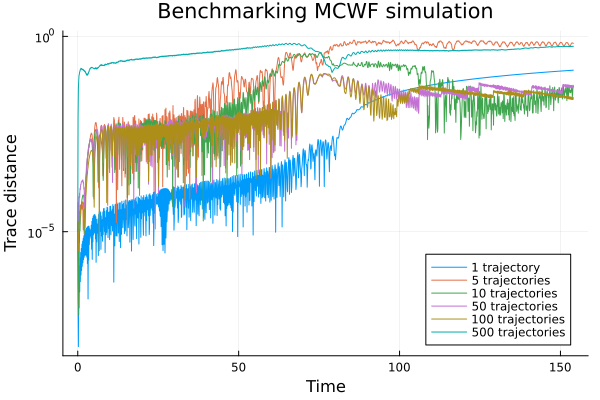

In [65]:
plot(tspan, T1, yscale=:log10, label="1 trajectory", xlabel="Time", ylabel="Trace distance", title="Benchmarking MCWF simulation",legend=:bottomright)
plot!(tspan, T5, label="5 trajectories")
plot!(tspan, T10, label="10 trajectories")
plot!(tspan, T50, label="50 trajectories")
plot!(tspan, T100, label="100 trajectories")
plot!(tspan, T500, label="500 trajectories")

In [11]:
basis = NLevelBasis(2)
k = transition(basis,2,2)
n_a = full_operator(k,total_qubits, [1])
n_c = full_operator(k, total_qubits, [3])
n_ac = full_operator(k, total_qubits, [1,3]);

pop_a1 = []
pop_aexact = []

for i in 1:length(ρt_exact)
    push!(pop_aexact , real(expect(n_ac, ρt_exact[i])))
    push!(pop_a1, real(expect(n_ac, ρt_500[i])))
end

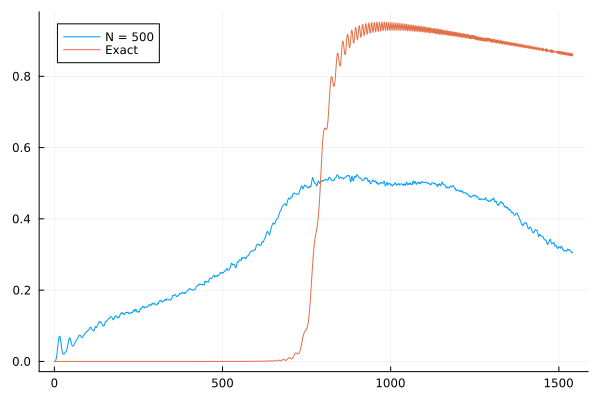

In [12]:
plot(pop_a1, label="N = 500")
plot!(pop_aexact, label="Exact")